# Analisis Runtun Waktu Kualitas Udara (Sentinel-5P)
**Studi Kasus:** Kabupaten Bangkalan, Madura (Agustus 2025 - Agustus 2026)

## 1. Business Understanding
**Tujuan Proyek:**
Memetakan dan memantau secara proaktif fluktuasi kualitas udara di wilayah Kabupaten Bangkalan menggunakan data penginderaan jauh satelit Sentinel-5P selama kurun waktu satu tahun terakhir

**Manfaat Proyek:**
1. **Sistem Peringatan Dini Kesehatan:** Memberikan peringatan berbasis data bagi masyarakat dan kelompok rentan saat angka polutan harian melonjak agar membatasi aktivitas *outdoor*
2. **Evaluasi Tata Ruang & Kebijakan:** Menjadi landasan objektif bagi instansi terkait maupun pengelola kawasan (seperti Universitas Trunojoyo Madura) untuk mengevaluasi kepadatan lalu lintas dan efektivitas ruang terbuka hijau
3. **Transparansi Informasi Publik:** Menerjemahkan matriks data satelit yang rumit menjadi grafik *time series* visual di portal web statis agar ancaman "polusi tak kasatmata" mudah dipahami oleh warga sipil

## 2. Data Understanding
Dataset ini berisi rekaman harian konsentrasi gas polutan yang diekstrak menggunakan agregasi spasial (*Polygon GeoJSON*) wilayah Bangkalan

**Deskripsi Fitur Polutan:**
* **CO (Karbon Monoksida):** *Silent killer* tak berbau dari pembakaran tidak sempurna, utamanya disumbang oleh asap knalpot kendaraan atau pembakaran sampah terbuka
* **NO₂ (Nitrogen Dioksida):** Gas reaktif pemicu radang pernapasan, berasal dari emisi mesin bahan bakar fosil (terutama diesel) dan aktivitas industri
* **O₃ (Ozon Permukaan):** Polutan sekunder berbahaya yang terbentuk dari reaksi kimia gas buang kendaraan di bawah terik matahari
* **SO₂ (Sulfur Dioksida):** Gas berbau menyengat penyebab hujan asam, umumnya dari pembakaran batu bara atau emisi bahan bakar kapal laut di area pesisir

**Catatan Eksplorasi Data (Anomali):**
Dalam data satelit optik, terdapat kondisi wajar yang perlu diperhatikan:
1. **Missing Values (NaN):** Terjadi ketika wilayah tertutup awan mendung/hujan, sehingga sensor satelit tidak dapat menembus permukaan bumi
2. **Outliers (Pencilan):** Lonjakan nilai ekstrem pada hari tertentu yang bisa merekam insiden nyata (kebakaran lahan) atau sekadar *noise* instrumen

## 3. Persiapan Lingkungan & Koneksi Server
Langkah teknis dimulai dengan memasang pustaka `openeo` dan mengautentikasi sistem lokal ke peladen Copernicus Data Space Ecosystem (CDSE). Koordinat Bangkalan didefinisikan menggunakan GeoJSON.

In [1]:
!pip install openeo pandas matplotlib
import openeo
import json
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.3 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
print("Menghubungkan ke CDSE Copernicus...")
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Menghubungkan ke CDSE Copernicus...


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=GVFQ-LZWL 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


### Step 1
Kita klik link yang di atas untuk melakukan verifikasi

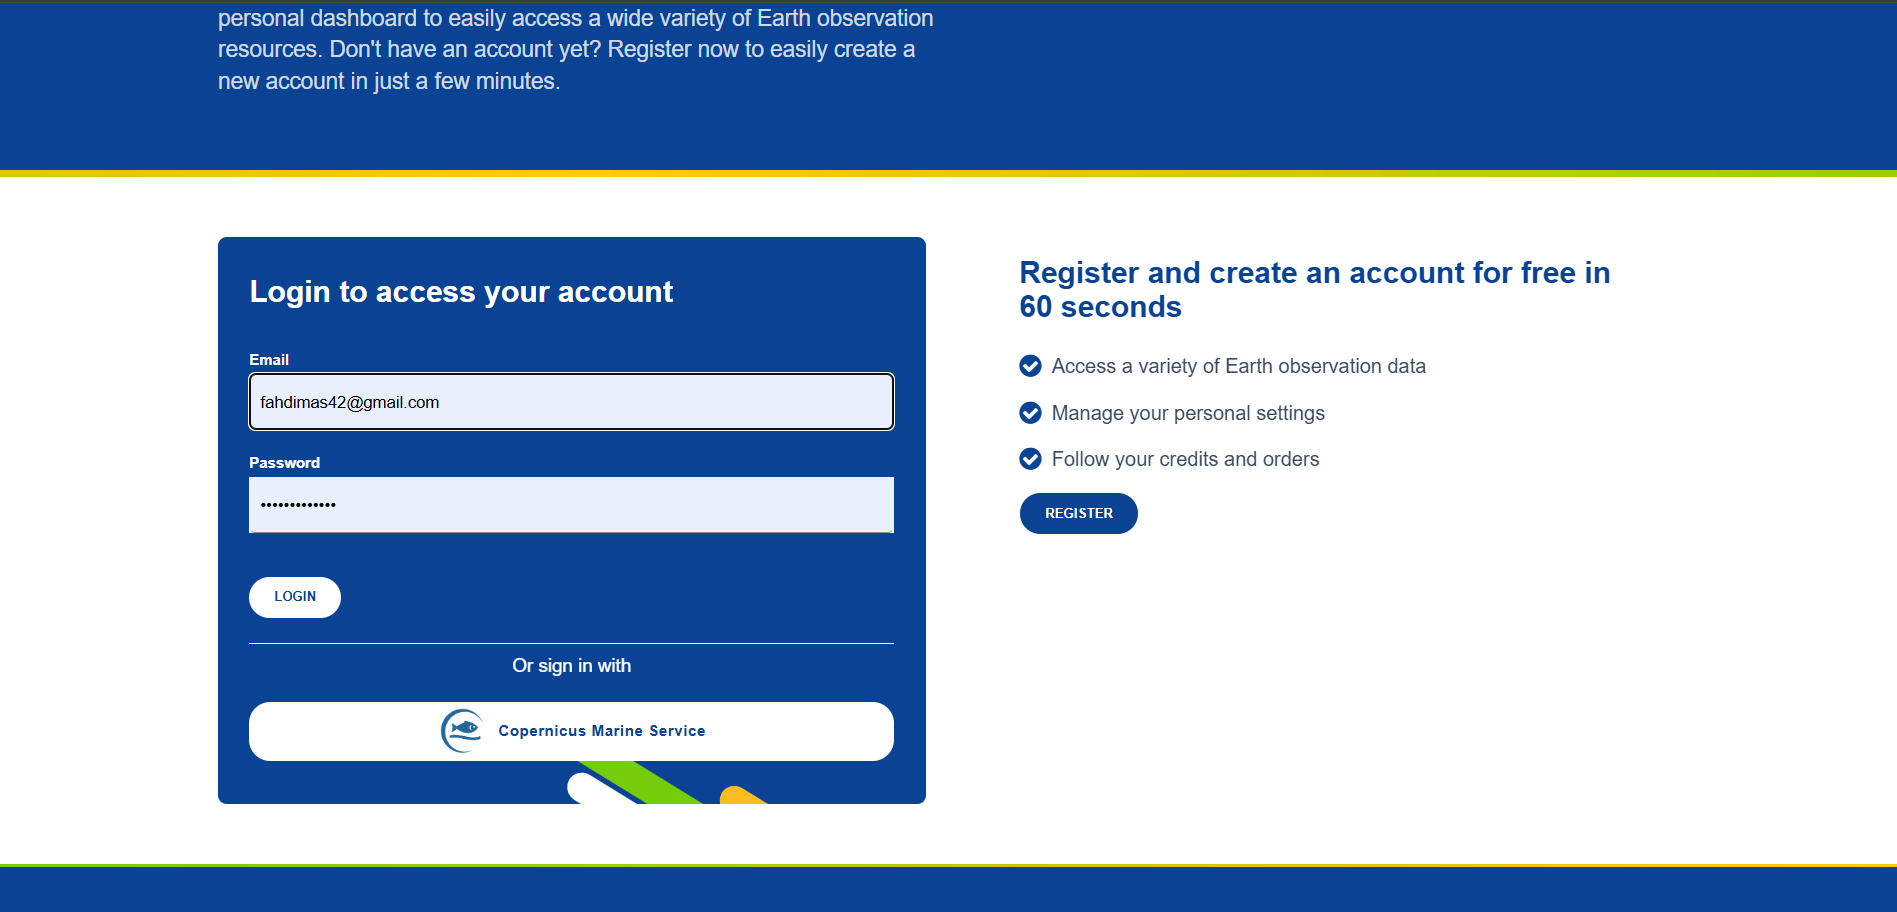

### Step 2
KIta melakukan Login pada account kita

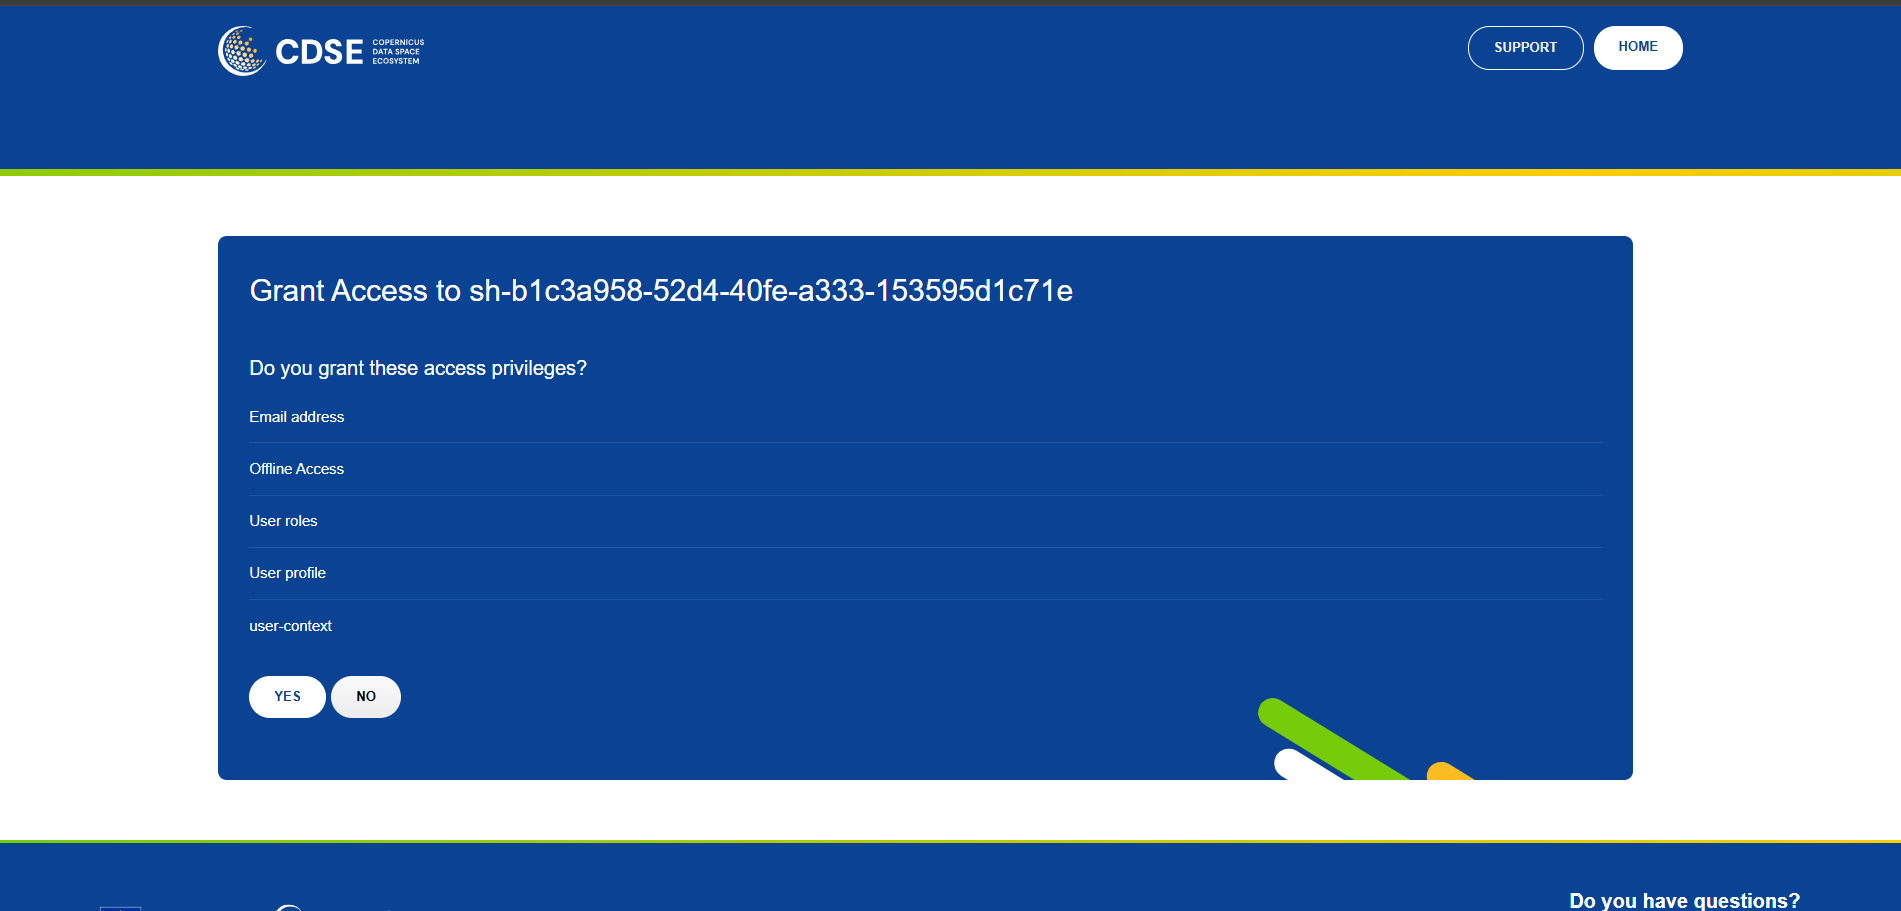

### step 3
Kita akan memilih yes untuk mengizin kan acces kepada account kita dan jika sudah maka akan muncul Device Login Succesful


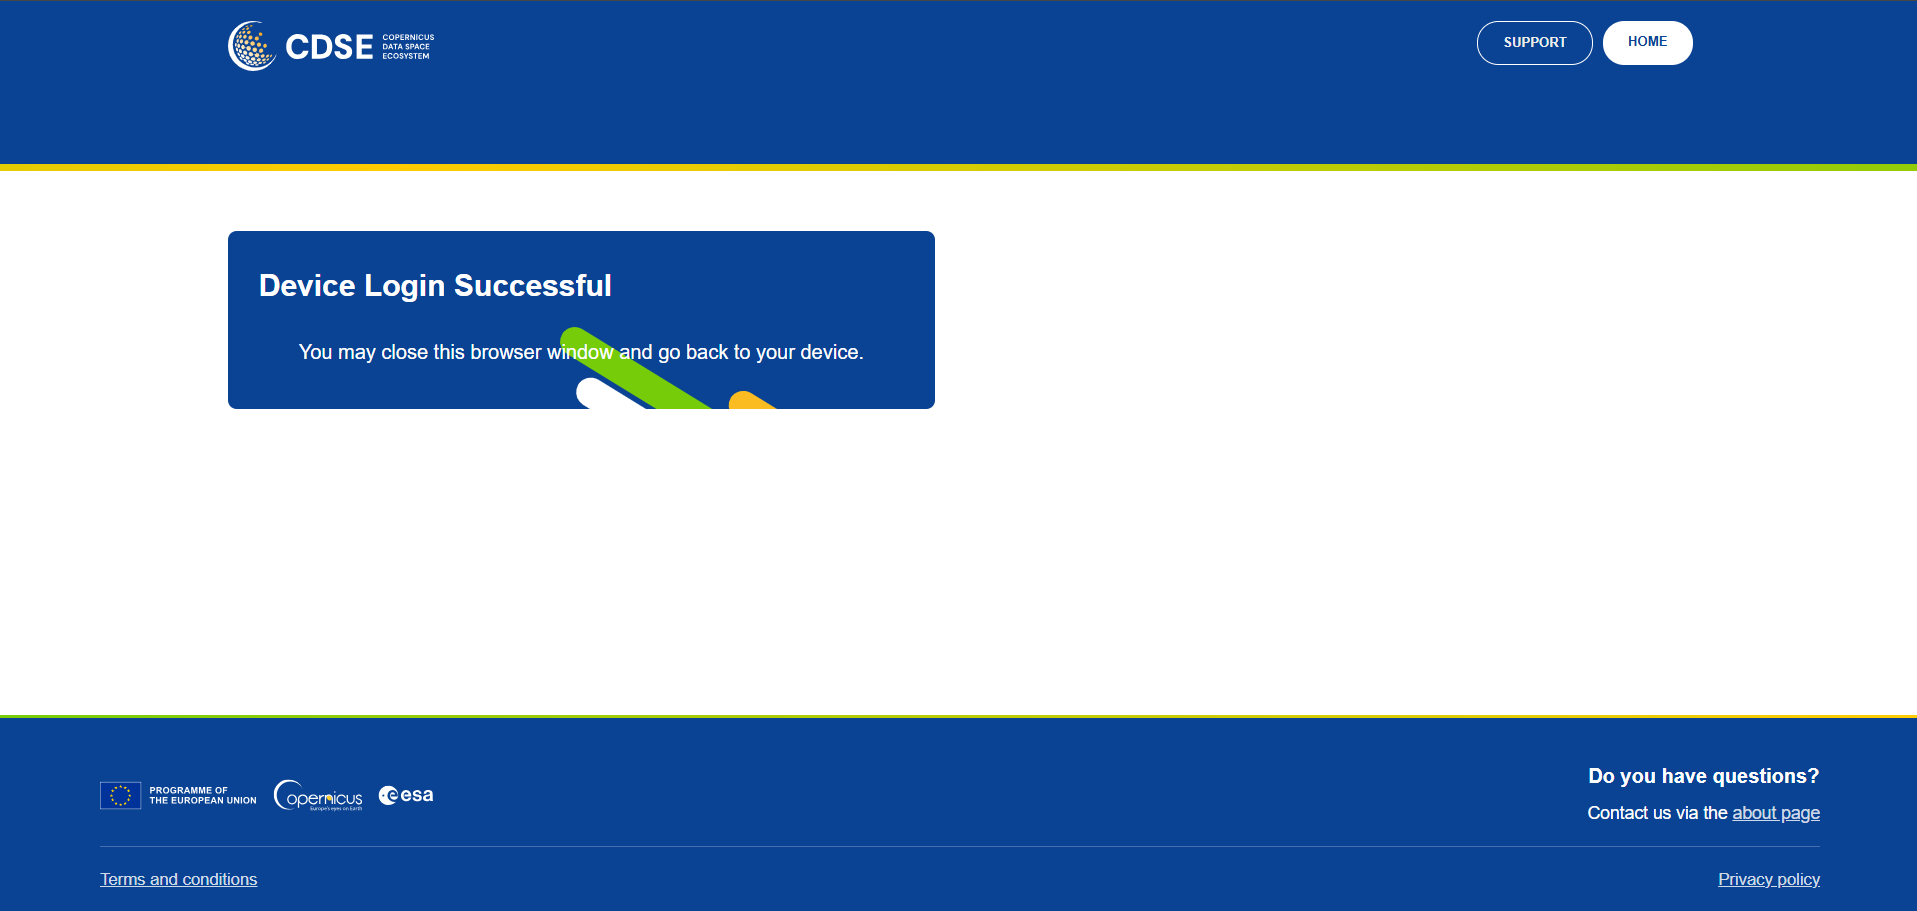

### Penetapan Koordinat Wilayah (GeoJSON)
Koordinat area Bangkalan dipetakan untuk membatasi pengambilan data satelit hanya pada wilayah studi.
Kita mengambil Koordinat daerah bangkalan menggunakan geojson.io

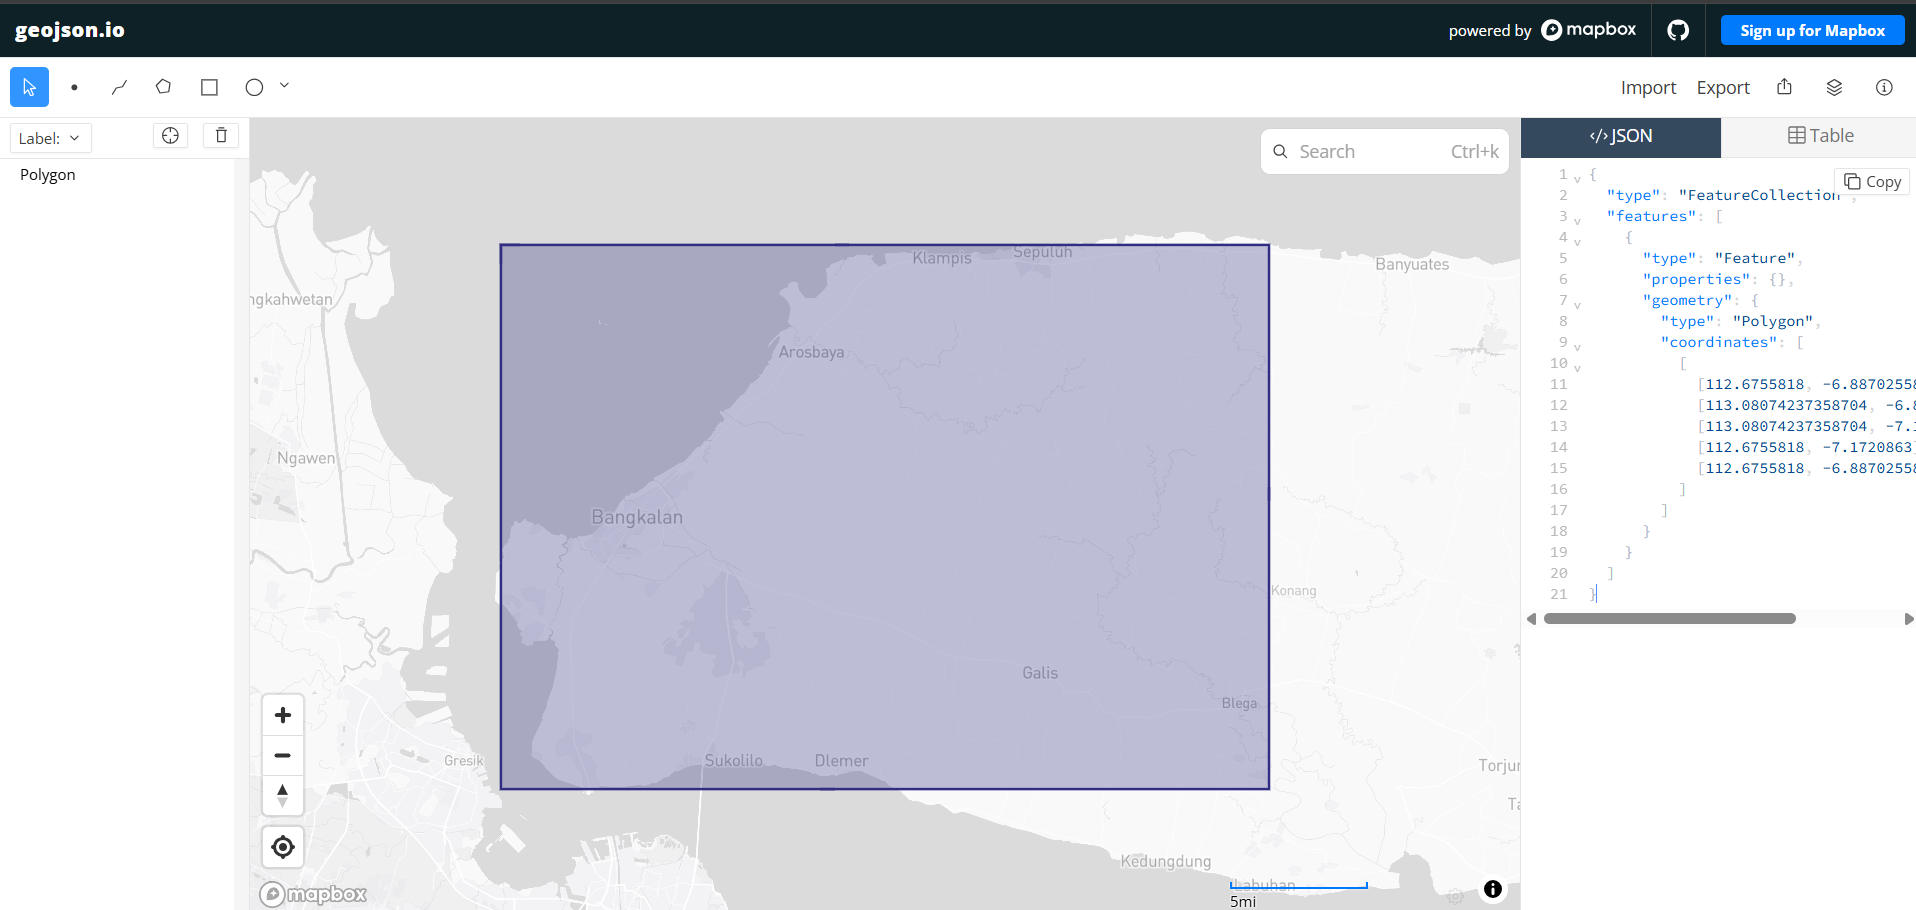

In [3]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [[112.6755818, -6.8870255898287525],
         [113.08074237358704, -6.8870255898287525],
         [113.08074237358704, -7.1720863],
         [112.6755818, -7.1720863],
         [112.6755818, -6.8870255898287525]]
    ]
}

## 4. Pengambilan Data Satelit
### 4.1 Ekstraksi Nitrogen Dioksida (NO₂)

In [6]:
gas_target = "NO2"
cube = connection.load_collection("SENTINEL_5P_L2", temporal_extent=["2025-08-01", "2026-08-31"], spatial_extent={"west": 112.6755818, "south": -7.1720863, "east": 113.08074237358704, "north": -6.8870255898287525}, bands=[gas_target])
cube_aoi = cube.aggregate_temporal_period(reducer="mean", period="day").aggregate_spatial(reducer="mean", geometries=aoi)

nc_filename = f"{gas_target}_Bangkalan.nc"
job = cube_aoi.execute_batch(title=f"{gas_target}_Bangkalan")
job.download_result(target=nc_filename)

with open(nc_filename, "r") as f:
    data_json = json.load(f)

records = [{'date': date_str, gas_target: (val[0][0] if val and val[0] else None)} for date_str, val in data_json.items()]
df_no2 = pd.DataFrame(records)
df_no2['date'] = pd.to_datetime(df_no2['date']).dt.date
df_no2.to_csv(f"{gas_target}_Bangkalan.csv", index=False)

0:00:00 Job 'j-2608301734474b298c4e56646d3be07e': send 'start'
0:00:02 Job 'j-2608301734474b298c4e56646d3be07e': created (progress 0%)
0:00:08 Job 'j-2608301734474b298c4e56646d3be07e': queued (progress 0%)
0:00:14 Job 'j-2608301734474b298c4e56646d3be07e': queued (progress 0%)
0:00:22 Job 'j-2608301734474b298c4e56646d3be07e': queued (progress 0%)
0:00:32 Job 'j-2608301734474b298c4e56646d3be07e': queued (progress 0%)
0:00:45 Job 'j-2608301734474b298c4e56646d3be07e': running (progress N/A)
0:01:00 Job 'j-2608301734474b298c4e56646d3be07e': running (progress N/A)
0:01:19 Job 'j-2608301734474b298c4e56646d3be07e': running (progress N/A)
0:01:44 Job 'j-2608301734474b298c4e56646d3be07e': running (progress N/A)
0:02:14 Job 'j-2608301734474b298c4e56646d3be07e': running (progress N/A)
0:02:51 Job 'j-2608301734474b298c4e56646d3be07e': running (progress N/A)
0:03:38 Job 'j-2608301734474b298c4e56646d3be07e': finished (progress 100%)


### 4.2 Ekstraksi Karbon Monoksida (CO)

In [7]:
gas_target = "CO"
cube = connection.load_collection("SENTINEL_5P_L2", temporal_extent=["2025-08-01", "2026-08-31"], spatial_extent={"west": 112.6755818, "south": -7.1720863, "east": 113.08074237358704, "north": -6.8870255898287525}, bands=[gas_target])
cube_aoi = cube.aggregate_temporal_period(reducer="mean", period="day").aggregate_spatial(reducer="mean", geometries=aoi)

nc_filename = f"{gas_target}_Bangkalan.nc"
job = cube_aoi.execute_batch(title=f"{gas_target}_Bangkalan")
job.download_result(target=nc_filename)

with open(nc_filename, "r") as f:
    data_json = json.load(f)

records = [{'date': date_str, gas_target: (val[0][0] if val and val[0] else None)} for date_str, val in data_json.items()]
df_co = pd.DataFrame(records)
df_co['date'] = pd.to_datetime(df_co['date']).dt.date
df_co.to_csv(f"{gas_target}_Bangkalan.csv", index=False)

0:00:00 Job 'j-2608301738324537b2d4e7d34f2080b3': send 'start'
0:00:02 Job 'j-2608301738324537b2d4e7d34f2080b3': queued (progress 0%)
0:00:07 Job 'j-2608301738324537b2d4e7d34f2080b3': queued (progress 0%)
0:00:14 Job 'j-2608301738324537b2d4e7d34f2080b3': queued (progress 0%)
0:00:22 Job 'j-2608301738324537b2d4e7d34f2080b3': queued (progress 0%)
0:00:32 Job 'j-2608301738324537b2d4e7d34f2080b3': queued (progress 0%)
0:00:44 Job 'j-2608301738324537b2d4e7d34f2080b3': queued (progress 0%)
0:01:00 Job 'j-2608301738324537b2d4e7d34f2080b3': queued (progress 0%)
0:01:19 Job 'j-2608301738324537b2d4e7d34f2080b3': running (progress N/A)
0:01:43 Job 'j-2608301738324537b2d4e7d34f2080b3': running (progress N/A)
0:02:13 Job 'j-2608301738324537b2d4e7d34f2080b3': running (progress N/A)
0:02:51 Job 'j-2608301738324537b2d4e7d34f2080b3': running (progress N/A)
0:03:38 Job 'j-2608301738324537b2d4e7d34f2080b3': finished (progress 100%)


### 4.3 Ekstraksi Ozon Permukaan (O₃)

In [8]:
gas_target = "O3"
cube = connection.load_collection("SENTINEL_5P_L2", temporal_extent=["2025-08-01", "2026-08-31"], spatial_extent={"west": 112.6755818, "south": -7.1720863, "east": 113.08074237358704, "north": -6.8870255898287525}, bands=[gas_target])
cube_aoi = cube.aggregate_temporal_period(reducer="mean", period="day").aggregate_spatial(reducer="mean", geometries=aoi)

nc_filename = f"{gas_target}_Bangkalan.nc"
job = cube_aoi.execute_batch(title=f"{gas_target}_Bangkalan")
job.download_result(target=nc_filename)

with open(nc_filename, "r") as f:
    data_json = json.load(f)

records = [{'date': date_str, gas_target: (val[0][0] if val and val[0] else None)} for date_str, val in data_json.items()]
df_o3 = pd.DataFrame(records)
df_o3['date'] = pd.to_datetime(df_o3['date']).dt.date
df_o3.to_csv(f"{gas_target}_Bangkalan.csv", index=False)

0:00:00 Job 'j-26083017421744f88ff8e5fb52ff7ada': send 'start'
0:00:02 Job 'j-26083017421744f88ff8e5fb52ff7ada': created (progress 0%)
0:00:07 Job 'j-26083017421744f88ff8e5fb52ff7ada': queued (progress 0%)
0:00:14 Job 'j-26083017421744f88ff8e5fb52ff7ada': running (progress N/A)
0:00:22 Job 'j-26083017421744f88ff8e5fb52ff7ada': running (progress N/A)
0:00:32 Job 'j-26083017421744f88ff8e5fb52ff7ada': running (progress N/A)
0:00:44 Job 'j-26083017421744f88ff8e5fb52ff7ada': running (progress N/A)
0:01:00 Job 'j-26083017421744f88ff8e5fb52ff7ada': running (progress N/A)
0:01:19 Job 'j-26083017421744f88ff8e5fb52ff7ada': running (progress N/A)
0:01:43 Job 'j-26083017421744f88ff8e5fb52ff7ada': running (progress N/A)
0:02:14 Job 'j-26083017421744f88ff8e5fb52ff7ada': running (progress N/A)
0:02:51 Job 'j-26083017421744f88ff8e5fb52ff7ada': running (progress N/A)
0:03:38 Job 'j-26083017421744f88ff8e5fb52ff7ada': finished (progress 100%)


### 4.4 Ekstraksi Sulfur Dioksida (SO₂)

In [9]:
gas_target = "SO2"
cube = connection.load_collection("SENTINEL_5P_L2", temporal_extent=["2025-08-01", "2026-08-31"], spatial_extent={"west": 112.6755818, "south": -7.1720863, "east": 113.08074237358704, "north": -6.8870255898287525}, bands=[gas_target])
cube_aoi = cube.aggregate_temporal_period(reducer="mean", period="day").aggregate_spatial(reducer="mean", geometries=aoi)

nc_filename = f"{gas_target}_Bangkalan.nc"
job = cube_aoi.execute_batch(title=f"{gas_target}_Bangkalan")
job.download_result(target=nc_filename)

with open(nc_filename, "r") as f:
    data_json = json.load(f)

records = [{'date': date_str, gas_target: (val[0][0] if val and val[0] else None)} for date_str, val in data_json.items()]
df_so2 = pd.DataFrame(records)
df_so2['date'] = pd.to_datetime(df_so2['date']).dt.date
df_so2.to_csv(f"{gas_target}_Bangkalan.csv", index=False)

0:00:00 Job 'j-26083017460243a5b6510830969eb531': send 'start'
0:00:02 Job 'j-26083017460243a5b6510830969eb531': queued (progress 0%)
0:00:08 Job 'j-26083017460243a5b6510830969eb531': queued (progress 0%)
0:00:14 Job 'j-26083017460243a5b6510830969eb531': queued (progress 0%)
0:00:23 Job 'j-26083017460243a5b6510830969eb531': queued (progress 0%)
0:00:32 Job 'j-26083017460243a5b6510830969eb531': queued (progress 0%)
0:00:45 Job 'j-26083017460243a5b6510830969eb531': queued (progress 0%)
0:01:00 Job 'j-26083017460243a5b6510830969eb531': running (progress N/A)
0:01:20 Job 'j-26083017460243a5b6510830969eb531': running (progress N/A)
0:01:44 Job 'j-26083017460243a5b6510830969eb531': running (progress N/A)
0:02:14 Job 'j-26083017460243a5b6510830969eb531': running (progress N/A)
0:02:52 Job 'j-26083017460243a5b6510830969eb531': finished (progress 100%)


### 4.5 Integrasi Master Dataset
Proses penggabungan file CSV dari setiap fitur polutan menjadi satu *dataframe* utuh untuk mempermudah pemeriksaan struktur dan analisis data lanjutan.

In [10]:
dfs = [df_no2, df_co, df_o3, df_so2]
for df in dfs:
    df['date'] = pd.to_datetime(df['date'])

df_merged = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), dfs)
df_merged = df_merged.sort_values('date').reset_index(drop=True)
df_merged.to_csv("KualitasUdara_Bangkalan.csv", index=False)

## 5. Eksplorasi Data (EDA)
Tahap eksplorasi data digunakan untuk menggali mengenai informasi awal, memahami karakteristik data, dan memastikan kelengkapan file hasil *crawling*.

### 5.1 Pemeriksaan Struktur & Tipe Data
Langkah ini untuk memastikan setiap parameter memiliki tipe data yang benar, seperti tanggal (`datetime`) dan nilai gas (`float`).

In [11]:
df = pd.read_csv("KualitasUdara_Bangkalan.csv")
df['date'] = pd.to_datetime(df['date'])

print("=== INFORMASI STRUKTUR & TIPE DATA KOLOM ===")
df.info()

=== INFORMASI STRUKTUR & TIPE DATA KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    396 non-null    datetime64[ns]
 1   NO2     310 non-null    float64       
 2   CO      299 non-null    float64       
 3   O3      391 non-null    float64       
 4   SO2     337 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 15.6 KB


### 5.2 Analisis Statistik Deskriptif
Menganalisis distribusi data yang meliputi nilai rata-rata, standar deviasi, nilai tengah (median), serta titik konsentrasi polutan minimum dan maksimum .

In [12]:
stat_desc = df.describe().T
stat_desc['median'] = df.median(numeric_only=True)
stat_desc = stat_desc[['count', 'mean', 'std', 'min', 'median', 'max']]

print("--- TABEL STATISTIK DESKRIPTIF KUALITAS UDARA BANGKALAN ---")
print(stat_desc)

--- TABEL STATISTIK DESKRIPTIF KUALITAS UDARA BANGKALAN ---
      count                 mean       std                  min    median  \
date    396  2026-02-13 12:00:00       NaN  2025-07-31 00:00:00       NaN   
NO2   310.0             0.000024  0.000009            -0.000005  0.000023   
CO    299.0             0.028633  0.002951             0.020487  0.028430   
O3    391.0             0.115724  0.002233             0.110363  0.115660   
SO2   337.0             0.000043  0.000145            -0.000947  0.000031   

                      max  
date  2026-08-30 00:00:00  
NO2              0.000056  
CO               0.044806  
O3               0.122673  
SO2              0.000969  


### 5.3 Pengecekan Missing Value
Pengecekan *missing values* ini dilakukan untuk mengetahui persentase data yang kosong atau hilang .

In [13]:
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
df_missing = pd.DataFrame({'Jumlah Missing Value': missing_count, 'Persentase (%)': missing_percentage})

print("--- LAPORAN PENGECEKAN MISSING VALUE ---")
print(df_missing)

--- LAPORAN PENGECEKAN MISSING VALUE ---
      Jumlah Missing Value  Persentase (%)
date                     0        0.000000
NO2                     86       21.717172
CO                      97       24.494949
O3                       5        1.262626
SO2                     59       14.898990


## 6. Deteksi Data Aneh (Outliers) & Visualisasi
Kadar polusi udara bisa saja memiliki anomali atau *outlier* akibat cuaca ekstrem atau lonjakan emisi tiba-tiba . Deteksi anomali ini menggunakan metode Interquartile Range (IQR) dengan batas bawah (*lower bound*) dan batas atas (*upper bound*) .

Visualisasi di bawah ini menampilkan fluktuasi *time series* dengan titik merah sebagai representasi *outlier* .

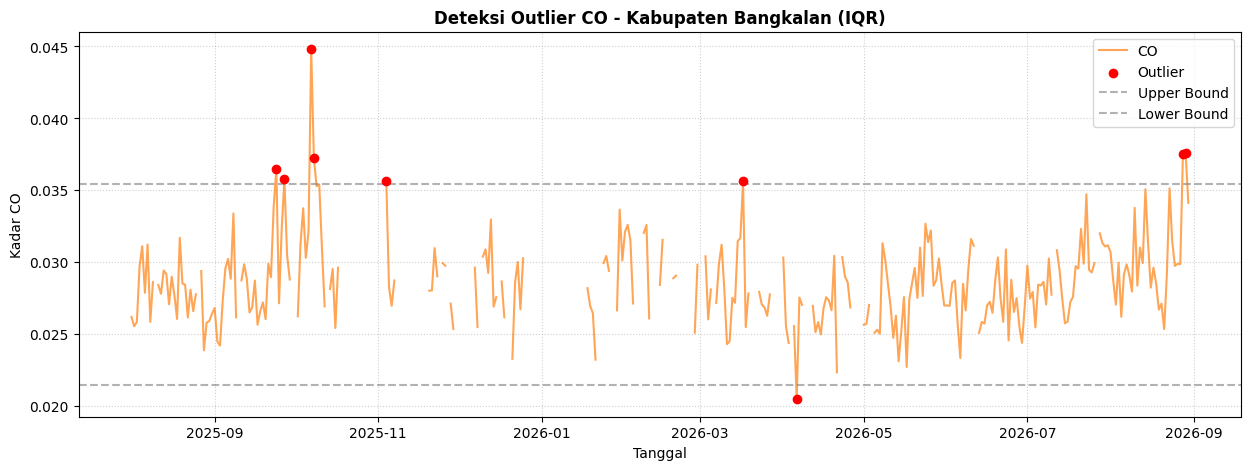

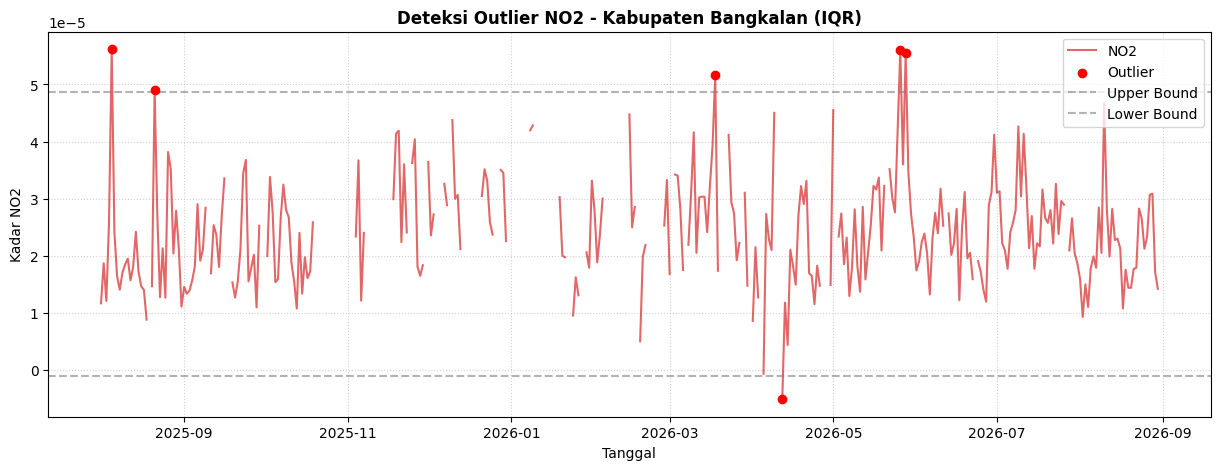

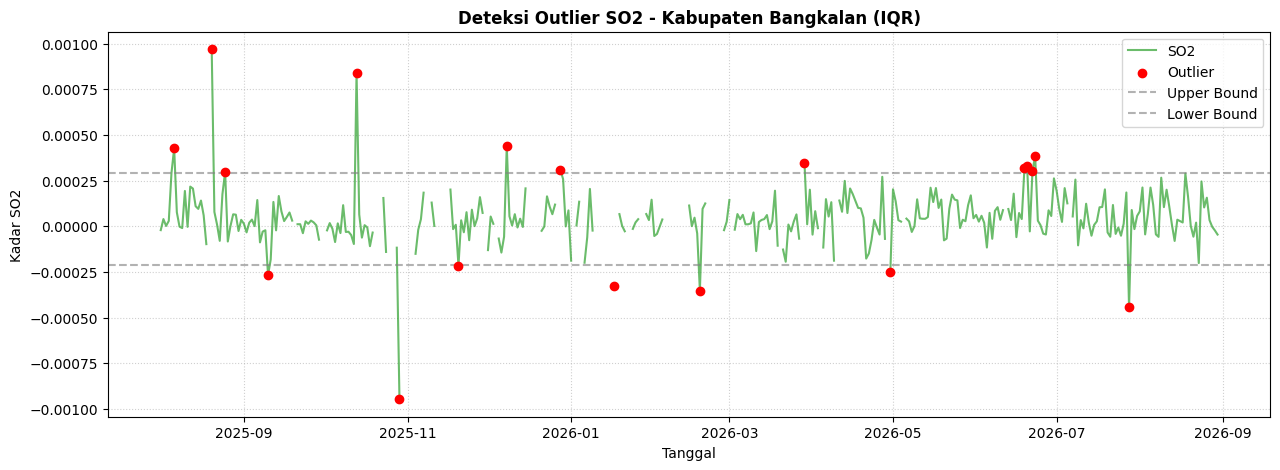

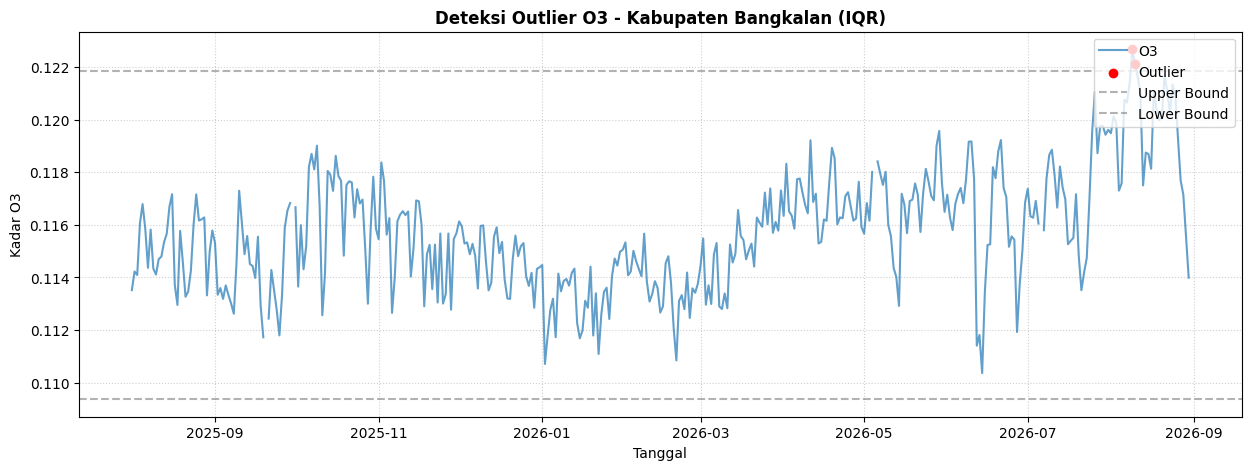

In [14]:

fitur_polutan = ['CO', 'NO2', 'SO2', 'O3']
warna_polutan = {'CO': 'tab:orange', 'NO2': 'tab:red', 'SO2': 'tab:green', 'O3': 'tab:blue'}

for kolom in fitur_polutan:
    if kolom in df.columns:
        Q1 = df[kolom].quantile(0.25)
        Q3 = df[kolom].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        outliers_iqr = df[(df[kolom] < lower_bound) | (df[kolom] > upper_bound)]


        plt.figure(figsize=(15, 5))
        plt.plot(df['date'], df[kolom], label=kolom, color=warna_polutan[kolom], alpha=0.7)
        plt.scatter(outliers_iqr['date'], outliers_iqr[kolom], color='red', label='Outlier', zorder=5)

        plt.axhline(upper_bound, color='grey', linestyle='dashed', label='Upper Bound', alpha=0.6)
        plt.axhline(lower_bound, color='grey', linestyle='dashed', label='Lower Bound', alpha=0.6)

        plt.title(f"Deteksi Outlier {kolom} - Kabupaten Bangkalan (IQR)", fontweight='bold')
        plt.xlabel("Tanggal")
        plt.ylabel(f"Kadar {kolom}")
        plt.legend(loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()